In [1]:
import os, json,cortex
import numpy as np
from config.dir import DATA_DIR,REPO_DIR
from sklearn.preprocessing import StandardScaler
from voxelwise_tutorials.delayer import Delayer
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.backend import set_backend
from sklearn.pipeline import make_pipeline
from voxelwise_tutorials.utils import generate_leave_one_run_out
from sklearn.model_selection import check_cv
import matplotlib.pyplot as plt
from utils.npp import zscore

# Using a single subject 3 for training & testing

In [2]:
subject = "sub-UTS01"
dir ='results/eng1000'
with open(os.path.join(REPO_DIR, dir,subject,'features_train.json'), "r") as f:
	X_train = json.load(f)
with open(os.path.join(REPO_DIR, dir,subject,'features_test.json'), "r") as f:
	X_test = json.load(f)
X_train = np.array(X_train, dtype=float)
X_test = np.array(X_test, dtype=float)
#X_train = np.vstack((X_train, X_train))
print("(n_samples_train, n_features) =", X_train.shape)
print("(n_samples_test, n_features) =", X_test.shape)

(n_samples_train, n_features) = (11414, 985)
(n_samples_test, n_features) = (291, 985)


In [3]:
print("Mean of features(train):",np.mean(X_train))
print("Standard deviation of features(train): ",np.std(X_train))
print("Mean of features(test) :",np.mean(X_test))
print("Standard deviation of features(test): ",np.std(X_test))

Mean of features(train): -7.513199163833951e-18
Standard deviation of features(train):  1.0
Mean of features(test) : -2.4590799932807207e-17
Standard deviation of features(test):  1.0


In [ ]:
with open(os.path.join(REPO_DIR, dir,subject,'fmri_train.json'), "r") as f:
	Y_train = json.load(f)
with open(os.path.join(REPO_DIR, dir,subject,'fmri_test.json'), "r") as f:
	Y_test = json.load(f)
Y_train = np.array(Y_train, dtype=float)
Y_test = np.array(Y_test, dtype=float)
print("(n_samples_train, n_voxels) =", Y_train.shape)
print("( n_samples_test, n_voxels) =", Y_test.shape)


In [ ]:
Y_test=zscore(Y_test)
where_are_NaNs = np.isnan(Y_train)
Y_train_n = Y_train.copy()
Y_train_n[where_are_NaNs] = 0
print("(n_samples_train, n_voxels) =", Y_train_n.shape)
print("Mean of fmri(train):",np.mean(Y_train_n))

(n_samples_train, n_voxels) = (11414, 81126)
Mean of fmri(train): -2.7030287913483092e-18


In [ ]:
print("Mean of fmri(train):",np.mean(Y_train_n))
print("Standard deviation of fmri(train):",np.std(Y_train_n))
print("Mean of fmri(test):",np.mean(Y_test))
print("Standard deviation of fmri(test):",np.std(Y_test))

Mean of fmri(train): -2.7030287913483092e-18
Standard deviation of fmri(train): 0.9999934663049282
Mean of fmri(test): 7.396876198621339e-18
Standard deviation of fmri(test): 1.0


# Get run onsets for cross-validation

In [ ]:
with open(os.path.join(REPO_DIR, dir,subject,'run_on.json'), "r") as f:
	run_onsets = json.load(f)
len(run_onsets)

32

In [ ]:
n_samples_train = X_train.shape[0]
cv = generate_leave_one_run_out(n_samples_train, run_onsets)
cv = check_cv(cv)  # copy the cross-validation splitter into a reusable list

In [ ]:
X_train_= X_train.astype("float32")
alphas = np.logspace(0, 28, 20)

In [ ]:
backend = set_backend("torch_cuda", on_error="warn")
print(backend)

<module 'himalaya.backend.torch_cuda' from '/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/backend/torch_cuda.py'>


# Create training model pipline 

In [ ]:
pipeline = make_pipeline(
    StandardScaler(with_mean=True, with_std=False),
    Delayer(delays=[1, 2, 3, 4]),
    KernelRidgeCV(
        alphas=alphas, cv=cv,
        solver_params=dict(n_targets_batch=500, n_alphas_batch=5,
                           n_targets_batch_refit=100)),
)

In [ ]:
_ = pipeline.fit(X_train, Y_train_n)

/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/kernel_ridge/_sklearn_api.py:490: UserWarning: Solving linear kernel ridge is slower than solving ridge when n_samples > n_features (here 11414 > 3940). Using himalaya.ridge.RidgeCV would be faster. Use warn=False to silence this warning.
  warnings.warn(
/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/backend/_utils.py:138: UserWarning: GPU backend torch_cuda is much faster with single precision floats (float32), got input in torch.float64. Consider casting your data to float32.
  warnings.warn(


# Scores of training and testing data set

In [ ]:
scores_train = pipeline.score(X_train, Y_train_n)
print("(n_voxels train,) =", scores_train.shape)
scores_test = pipeline.score(X_test, Y_test)
print("(n_voxels test,) =", scores_test.shape)

(n_voxels train,) = torch.Size([81126])
(n_voxels test,) = torch.Size([81126])


In [32]:
subject = 'sub-UTS01'
train_predict=pipeline.predict(X_train)
test_predict=pipeline.predict(X_test)
np.save(os.path.join(REPO_DIR, dir,subject,'train_predict'), train_predict.cpu().numpy())
np.save(os.path.join(REPO_DIR, dir,subject,'test_predict'), test_predict.cpu().numpy())

Text(0.5, 0, 'R-squared')

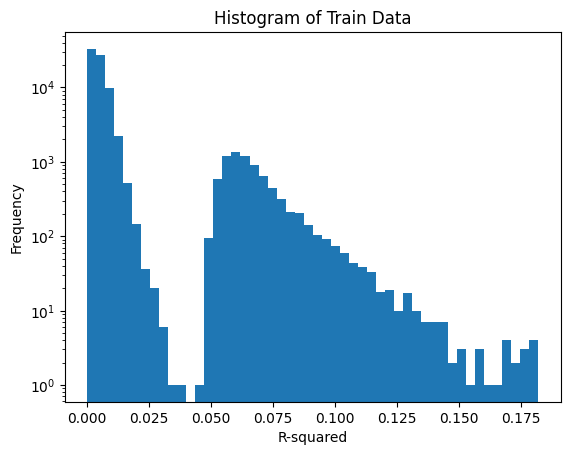

In [ ]:
plt.hist(scores_train.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Train Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

Text(0.5, 0, 'R-squared')

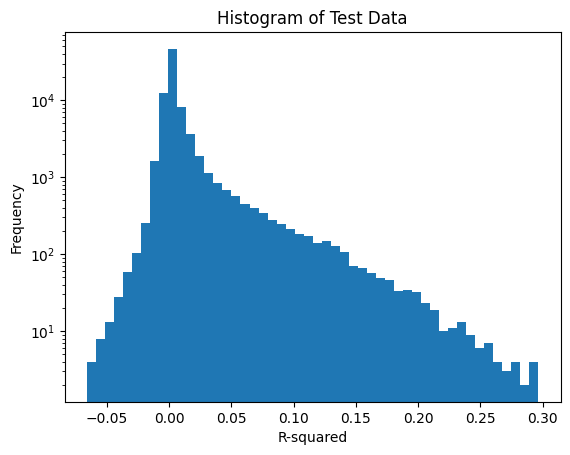

In [ ]:
plt.hist(scores_test.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Test Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

# Save trained data 

In [23]:
subject = "sub-UTS01"
#scores_train = np.loadtxt('train.txt', dtype=float)
np.save(os.path.join(REPO_DIR, dir,subject,'scores_train'), scores_train.cpu().numpy())
np.save(os.path.join(REPO_DIR, dir,subject,'scores_test'), scores_test.cpu().numpy())
#scores_test = np.loadtxt('test.txt', dtype=float)

# plotting on pycortex

In [17]:
def set_pycortex_store(filestore):
    """Set the pycortex store to the specified directory."""
    cortex.database.default_filestore = filestore
    cortex.db.filestore = filestore
    cortex.db.reload_subjects()
    print(f"pycortex store set to {filestore}")


In [18]:
set_pycortex_store(os.path.join(DATA_DIR, 'ds003020/derivative/pycortex-db'))

pycortex store set to /home/ckj24/genevieve/ds003020/derivative/pycortex-db


# Training data score 

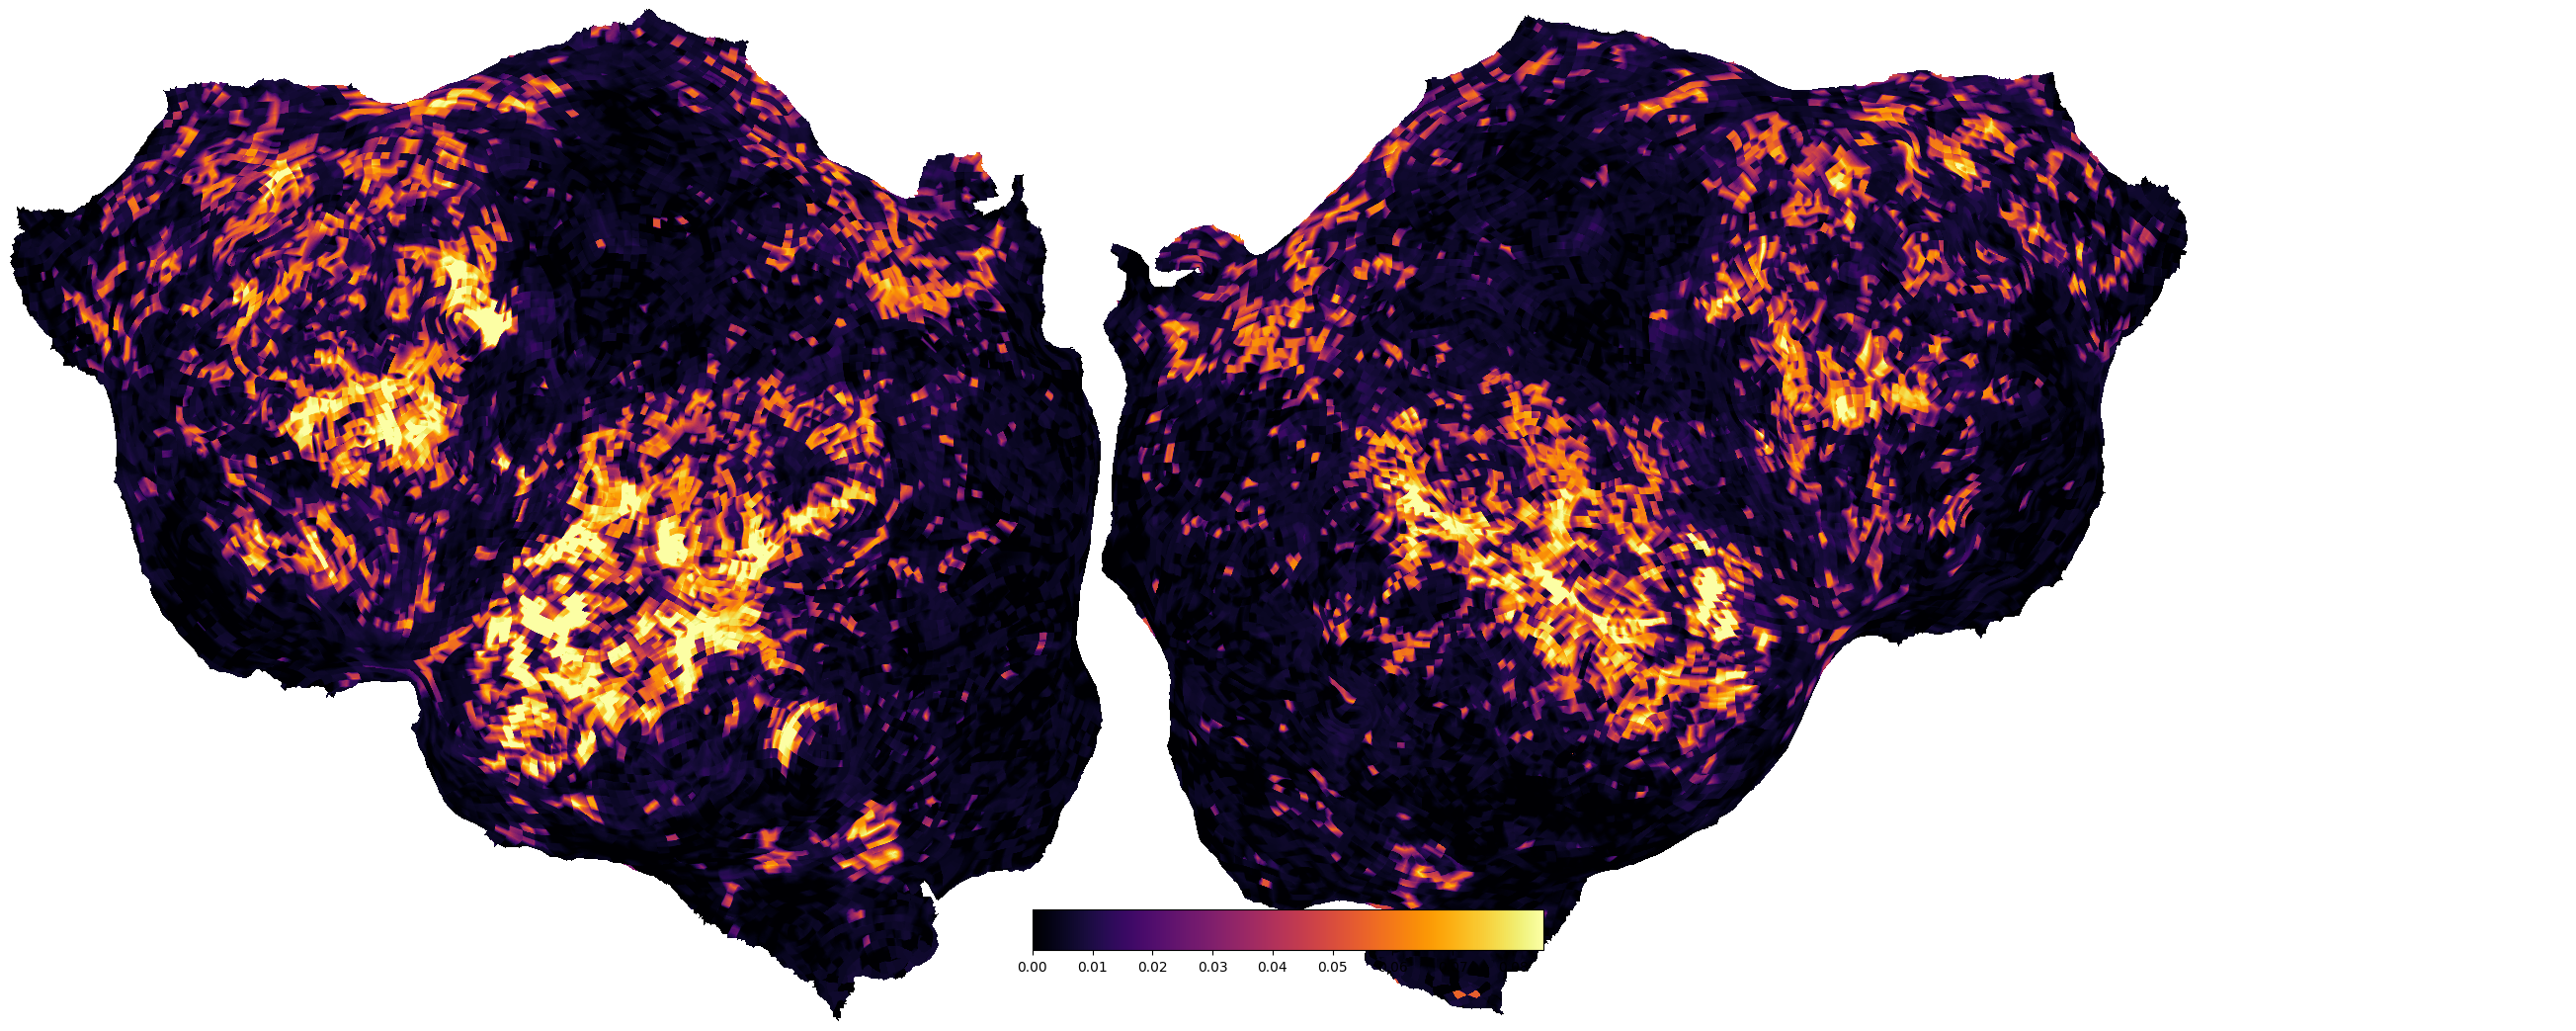

In [19]:
subject = 'UTS01'
xfm = 'UTS01_auto'

# First create example voxel data for this subject and transform
voxel_data = scores_train.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm, 'line_nearest', recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

# Test data score

Caching mapper...


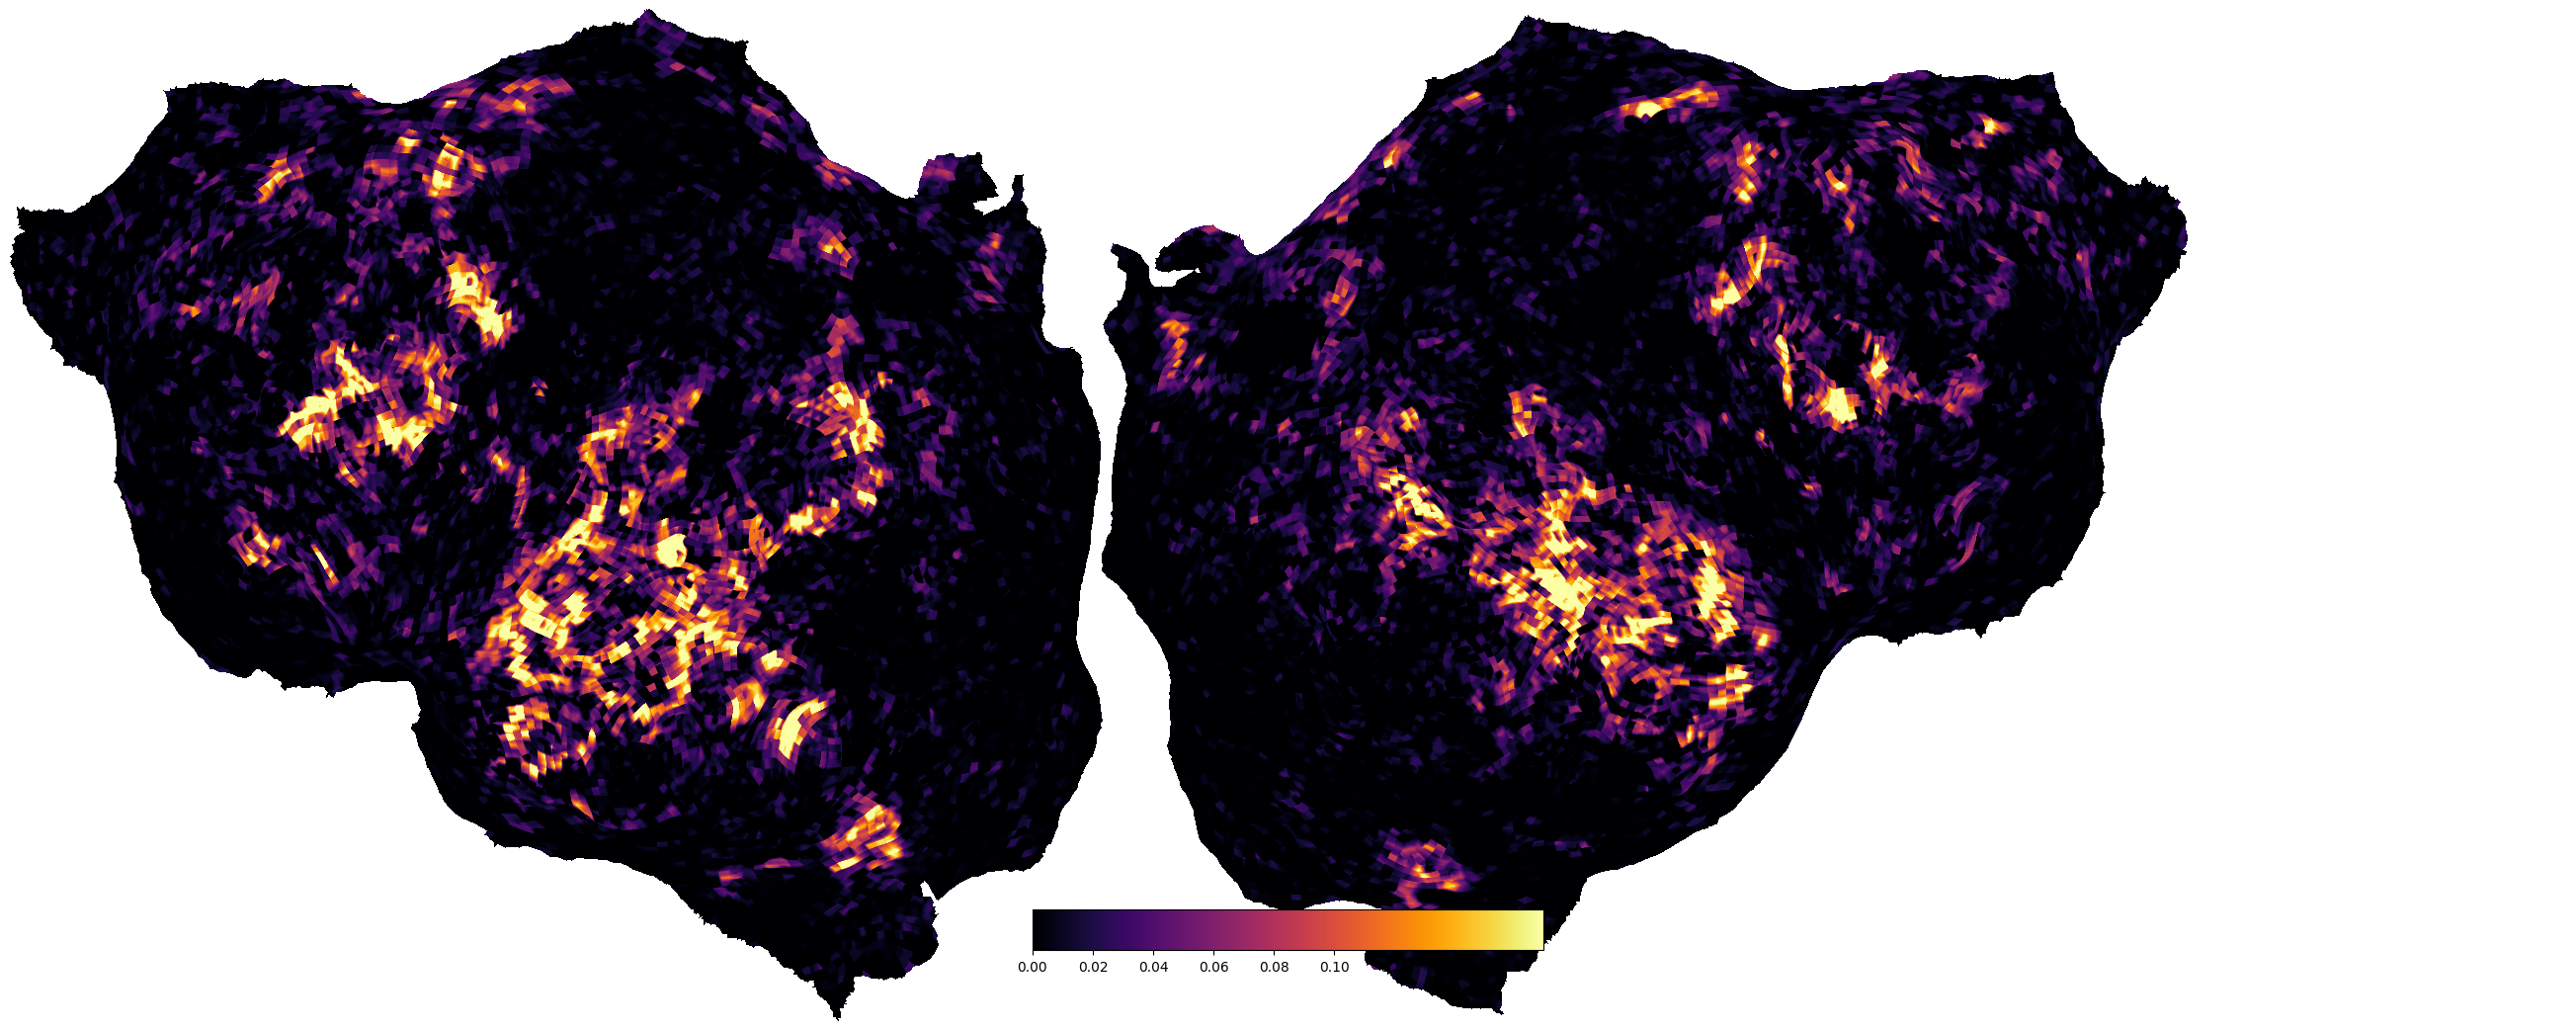

In [20]:
# First create example voxel data for this subject and transform
voxel_data = scores_test.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,vmin=0,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm,  recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

<Axes: xlabel='log10(alpha)', ylabel='Number of targets'>

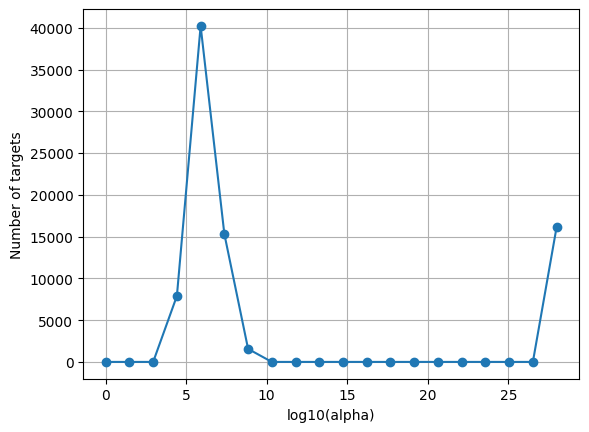

In [21]:
from himalaya.viz import plot_alphas_diagnostic
best_alphas = backend.to_numpy(pipeline[-1].best_alphas_)
plot_alphas_diagnostic(best_alphas=best_alphas, alphas=alphas)